In [10]:
from typing import TypedDict
from langgraph.graph import END, START, StateGraph


# State Schema
class BatsmanState(TypedDict):
    runs: int
    balls: int
    foures: int
    sixes: int
    sr: float
    bpb: float
    boundary_percent: float
    summary: str


# Node 1: Strike Rate (SR) calculate karna
def calculate_sr(state: BatsmanState) -> dict:
    runs = state["runs"]
    balls = state["balls"]

    sr = (runs / balls) * 100 if balls > 0 else 0.0
    return {"sr": round(sr, 2)}


# Node 2: Balls Per Boundary (BPB) & Boundary Percent calculate karna
def calculate_boundary_stats(state: BatsmanState) -> dict:
    runs = state["runs"]
    balls = state["balls"]
    fours = state["foures"]
    sixes = state["sixes"]

    total_boundaries = fours + sixes
    boundary_runs = (fours * 4) + (sixes * 6)

    # Balls per boundary
    bpb = balls / total_boundaries if total_boundaries > 0 else 0.0

    # Boundary percentage (runs percentage from boundaries)
    boundary_percent = (boundary_runs / runs) * 100 if runs > 0 else 0.0

    return {"bpb": round(bpb, 2), "boundary_percent": round(boundary_percent, 2)}


# Node 3: Summary generate karna
def generate_summary(state: BatsmanState) -> dict:
    summary_text = (
        f"Batsman scored {state['runs']} runs in {state['balls']} balls "
        f"with a SR of {state['sr']}. Boundaries percentage: {state['boundary_percent']}%."
    )
    return {"summary": summary_text}



# Graph Build Karein
graph = StateGraph(BatsmanState)

# Nodes Add Karein
graph.add_node("calculate_sr", calculate_sr)
graph.add_node("calculate_boundary_stats", calculate_boundary_stats)
graph.add_node("generate_summary", generate_summary)

# Edges Add Karein (Sequence)
graph.add_edge(START, "calculate_sr")
graph.add_edge("calculate_sr", "calculate_boundary_stats")
graph.add_edge("calculate_boundary_stats", "generate_summary")
graph.add_edge("generate_summary", END)

# Graph Compile Karein
workflow = graph.compile()

# Invoke
initial_state = {"runs": 100, "balls": 50, "foures": 6, "sixes": 4}

final_state = workflow.invoke(initial_state)
print(final_state)

{'runs': 100, 'balls': 50, 'foures': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0, 'summary': 'Batsman scored 100 runs in 50 balls with a SR of 200.0. Boundaries percentage: 48.0%.'}


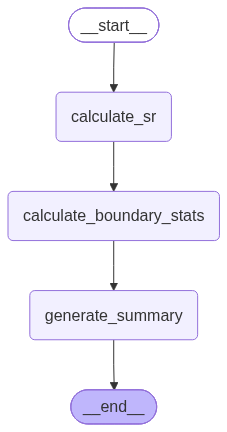

In [11]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())